### Read the Snow17 and SNOWPACK Test1/ Output and Compare with Obs: PPSA2

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [5]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa2/output/hrrrak_ppsa2_WY2025_hrrrak_ppsa2_WY2025.smet")

print(ds_snowpack)
print(header)

<xarray.Dataset> Size: 4MB
Dimensions:               (timestamp: 8756)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 70kB 2024-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 70kB 266.5 266.7 ... 67.14 69.81
    Ql                    (timestamp) float64 70kB 189.9 223.6 ... 21.73 23.63
    Qg                    (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 70kB -999.0 -999.0 ... -999.0
    Qr                    (timestamp) float64 70kB 4.095 2.344 1.09 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Ss                    (timestamp) float64 70kB 6.0 6.0 6.0 ... 6.0 6.0 6.0
    zS4                   (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S4                    (timestamp) float64 70kB 6.0 6.0 6.0 ... 6.0 

/tmp/ipykernel_1512790/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open PPSA2 Station Observations

In [58]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met_raw = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met_raw['datetime'] = pd.to_datetime(df_met_raw['utc_valid'], utc=True)
df_met_raw = df_met_raw.set_index('datetime')

# quick clean 
df_met = df_met_raw.copy()
df_met['hs'] = df_met['SDIRZZZ'].where(
    (df_met['SDIRZZZ'] >= 0) & (df_met['SDIRZZZ'] <= 200)
)

df_met = df_met.loc['2024-10-01':'2025-10-10', ['hs']]

# The raw data is in inches, convert to cm
df_met = df_met * 2.54

df_met

,hs
datetime,
2024-10-01 00:00:00+00:00,43.1038
2024-10-01 01:00:00+00:00,42.1132
2024-10-01 02:00:00+00:00,42.8752
2024-10-01 03:00:00+00:00,41.0972
2024-10-01 04:00:00+00:00,43.6626
...,...
2025-05-31 20:00:00+00:00,41.8592
2025-05-31 21:00:00+00:00,40.8178
2025-05-31 22:00:00+00:00,42.5704


In [45]:
# Clean it up: Apply masks for specific months and thresholds
# October: if hs > 50, set to NaN
mask_oct = (df_met.index.month == 10) & (df_met['hs'] > 25)
df_met.loc[mask_oct, 'hs'] = np.nan

# October and November and December: if hs < 5, set to NaN
mask_oct_nov = (df_met.index.month.isin([10, 11, 12])) & (df_met['hs'] < 5)
df_met.loc[mask_oct_nov, 'hs'] = np.nan

# February, March, April, May: if hs > 200, set to NaN
mask_feb_may = (df_met.index.month.isin([2, 3, 4, 5])) & (df_met['hs'] > 200)
df_met.loc[mask_feb_may, 'hs'] = np.nan

# Optional: Print summary of changes
print(f"October values set to NaN: {mask_oct.sum()}")
print(f"Feb-May values set to NaN: {mask_feb_may.sum()}")
print(f"Total NaN values in 'hs': {df_met['hs'].isna().sum()}")

October values set to NaN: 0
Feb-May values set to NaN: 0
Total NaN values in 'hs': 984


Text(0, 0.5, 'snow depth (cm)')

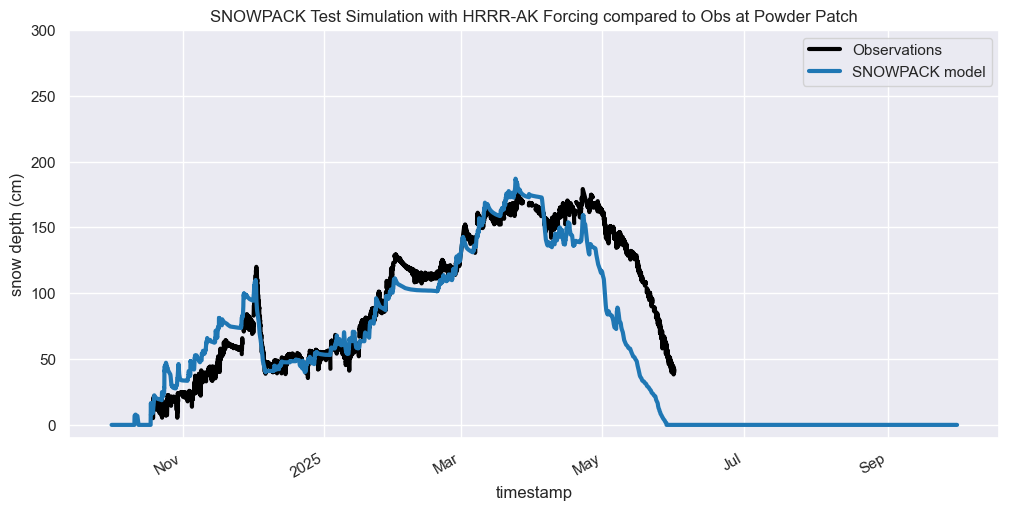

In [57]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color='black')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### Open Snow-17 Output 

In [47]:
# /home/cassie/python/models/run_snow17/test1/output/output.snow17bmi.hrrrak_ppsa2_test1.txt
filepath = '/home/cassie/python/models/run_snow17/sites/ppsa2/output/'
filename = 'output.snow17bmi.hrrrak_ppsa2_WY2025.txt'

fullpath = os.path.join(filepath, filename)

# df_snow17 = pd.read_csv(fullpath) # use delimiter = '\t' or ',' if comma-separated 
df_snow17 = pd.read_csv(fullpath, sep=r'\s+', header=0) # using delim_whitespaced worked for the header, this is needed for the data to separate correctly

# change the name 'mo' to 'month, 'dy' to 'day', 'hr' to 'hour'
df_snow17.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'}, inplace=True)
df_snow17.head()

# now, create a datetime object from the year, month, day, hour, minute columns
df_snow17['datetime'] = pd.to_datetime(df_snow17[['year', 'month', 'day', 'hour']])
# index by datetime 
df_snow17.set_index('datetime', inplace=True)
df_snow17.head()

,year,mo,dy,hr,tair,precip,precip*scf,sneqv,snowh,raim
0,2024,10,1,5,4.77,0.936,1.685,0.0,0.0,0.936
1,2024,10,1,6,5.07,0.504,0.907,0.0,0.0,0.504
2,2024,10,1,7,5.50,0.216,0.389,0.0,0.0,0.216
3,2024,10,1,8,4.96,0.000,0.000,0.0,0.0,0.000
4,2024,10,1,9,4.86,0.324,0.583,0.0,0.0,0.324


# Plot all together

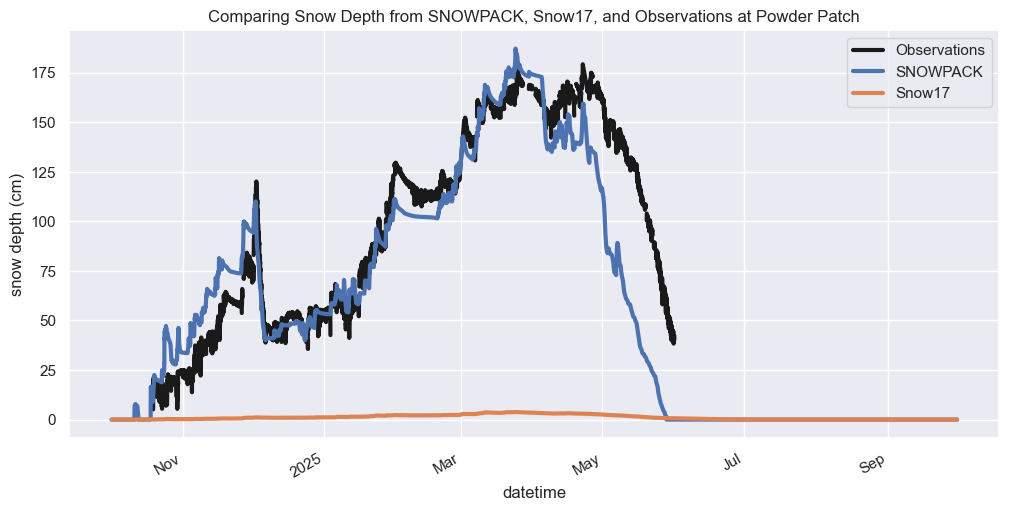

In [50]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.snowh).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

Snow depth from Snow-17 looks like it's in meters, so multiply by 100

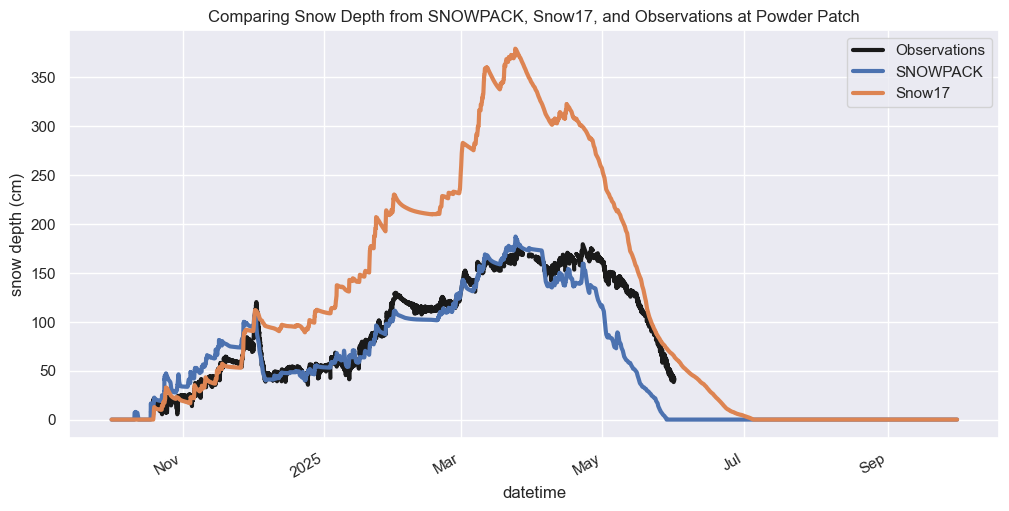

In [51]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.snowh*100).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

If we multiply it by a factor of something, like 20/50, 

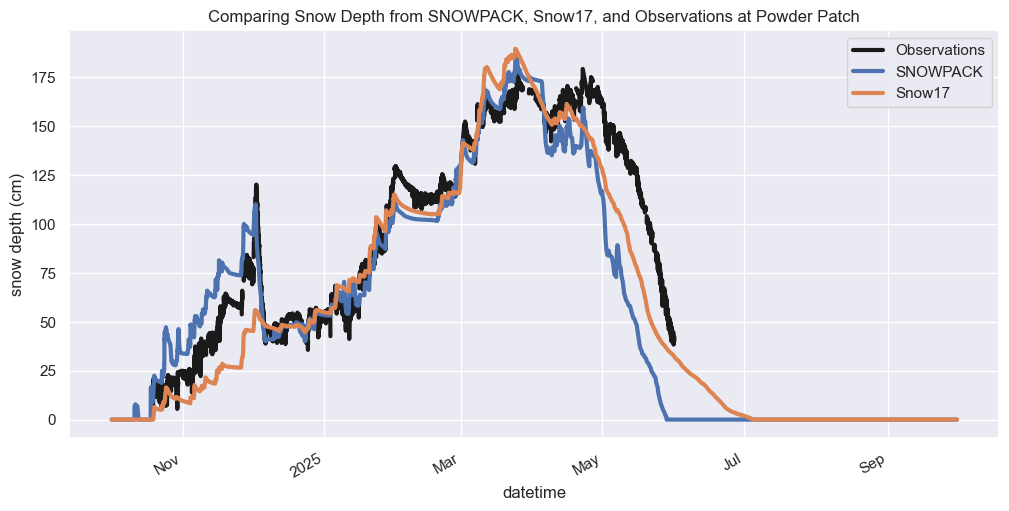

In [52]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.snowh*50).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

Okay, it does look better like that but I'm not sure what's going on. I'll have to look into it more. 

### Compare SWE from SNOWPACK and Snow-17

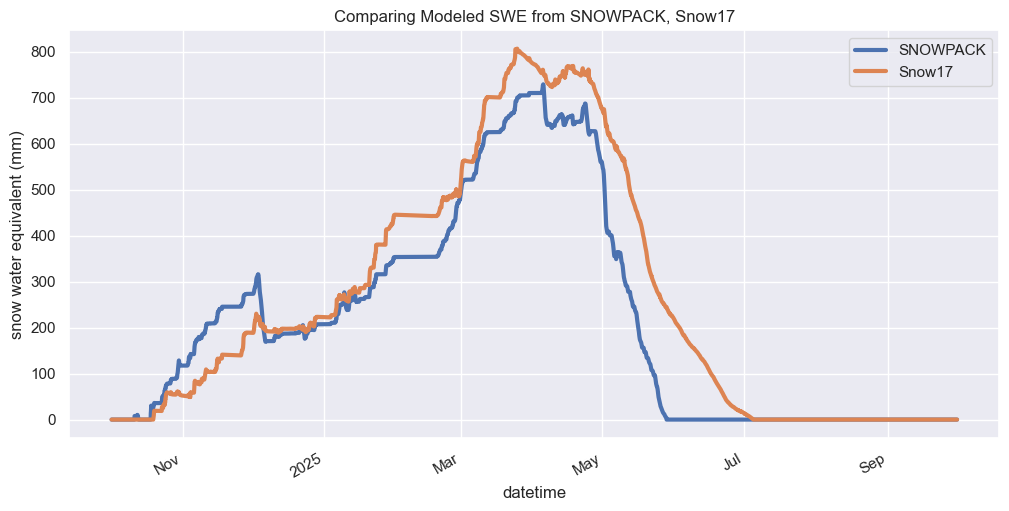

In [53]:
# SWE
ds_snowpack.SWE.plot(label = 'SNOWPACK', linewidth = 3)
(df_snow17.sneqv).plot(label = 'Snow17', linewidth = 3)

plt.title('Comparing Modeled SWE from SNOWPACK, Snow17')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow water equivalent (mm)')
plt.show()

#### Trying to understand Snow17 Model Output....

In [17]:
df_snow17.head()

,year,month,day,hour,tair,precip,precip*scf,sneqv,snowh,raim
datetime,,,,,,,,,,
2024-10-01 05:00:00,2024,10,1,5,4.77,0.936,1.685,0.0,0.0,0.936
2024-10-01 06:00:00,2024,10,1,6,5.07,0.504,0.907,0.0,0.0,0.504
2024-10-01 07:00:00,2024,10,1,7,5.50,0.216,0.389,0.0,0.0,0.216
2024-10-01 08:00:00,2024,10,1,8,4.96,0.000,0.000,0.0,0.0,0.000
2024-10-01 09:00:00,2024,10,1,9,4.86,0.324,0.583,0.0,0.0,0.324


*Snow17 Output*
| Variable | Meaning    | Typical units                               |
| -------- | ---------- | ------------------------------------------- |
| `tair  ` | temp       | degree C                                    |
| `precip` | precip     | mm per timestep (hour)                      |
| `sneqv`  | SWE        | mm                                          |
| `snowh`  | Snow depth | **meters** or **inches** depending on build |

based on our values of `sneqv` from 0-3, then it's likely in meters.

Since Snow-17 is not a physical snowpack model, and snow depth is a diagnostic variable derived from SWE using a simple density assumption.\
Maybe it's something like, snow depth = modeled SWE / constant snow density\
Not positive... 


#### Create our own snow depth, with any density and modeled SWE 

1 mm SWE = 1 kg/m² water\
HS (m) = SWE (kg/m²) / ρsnow (kg/m³)\
SWE (kg/m²) = SWE (mm)\

In [55]:
# we can make our own variable for snow depth which is calcualted by a density we decide 
rho_snow = 300  # snow density in kg/m3
df_snow17['HS_calc_cm'] = df_snow17['sneqv'] * (100 / rho_snow)

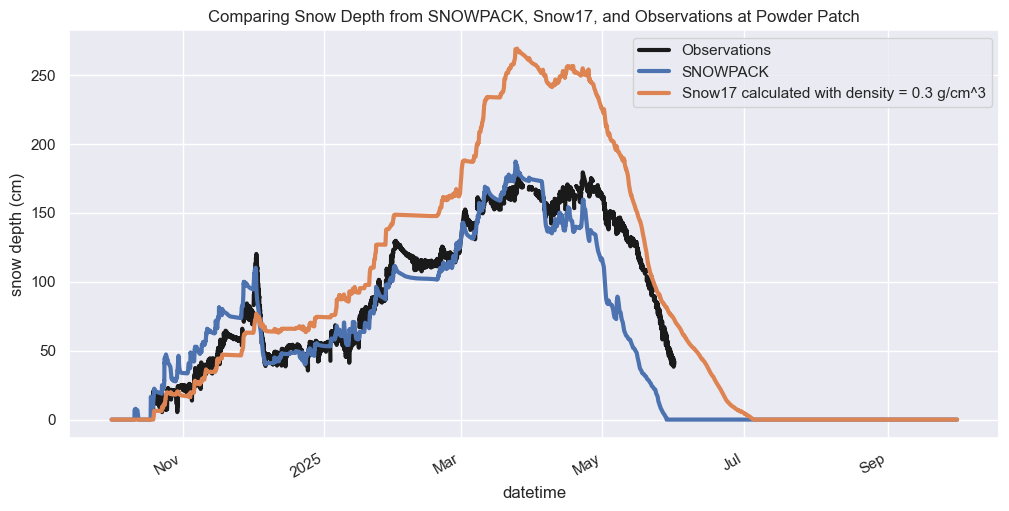

In [56]:
df_met.hs.plot(label = 'Observations', linewidth = 3, color = 'k')
ds_snowpack.HS_mod.plot(label = 'SNOWPACK', linewidth = 3)
df_snow17.HS_calc_cm.plot(label = 'Snow17 calculated with density = 0.3 g/cm^3', linewidth = 3)

plt.title('Comparing Snow Depth from SNOWPACK, Snow17, and Observations at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')
plt.show()

That looks bad still. 

I did test the precip input, and it's certainly not that. 